# Ejercicio 7. Comunidades

Detectar comunidades en esta red tiene una dificultad que conviene poner por
delante: el ejercicio 6 mostró que la red ya viene partida en 10 componentes
desconectadas y que el 97.3 % de los autores comentó en un solo video. En una
estructura así, cualquier algoritmo de comunidades va a encontrar,
básicamente, los videos. La pregunta interesante no es *cuántas comunidades
hay* sino **si el algoritmo encuentra algo que no sea simplemente la lista de
videos**, y este cuaderno la responde comparando la partición hallada contra
esa partición trivial.

In [1]:
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from networkx.algorithms.community import louvain_communities, modularity

from src import config, datos, redes, sentimiento as sen, texto as txt

warnings.filterwarnings("ignore")
config.preparar_directorios()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 170)

videos = datos.cargar_videos()
comentarios = txt.agregar_versiones(datos.cargar_comentarios())
comentarios = sen.agregar_sentimiento(comentarios, "texto_original")

B = redes.construir_bipartita(comentarios, videos)
PA = redes.proyeccion_autores(B)

print(f"Bipartita  : {B.number_of_nodes()} nodos, {B.number_of_edges()} aristas")
print(f"Autor-autor: {PA.number_of_nodes()} nodos, {PA.number_of_edges()} aristas")

Bipartita  : 351 nodos, 343 aristas
Autor-autor: 332 nodos, 10732 aristas


## 7.1 Qué red se usa y por qué

Se detectan comunidades sobre la **red bipartita autor-video**, no sobre la
proyección autor-autor. Tres razones:

**1. La proyección da un resultado que ya se conoce de antemano.** Proyectar
convierte cada video en un grupo completo. Correr Louvain ahí es preguntarle
a un algoritmo que encuentre los grupos que el propio preprocesamiento acaba
de construir. Más abajo se corre igual, para mostrar empíricamente que eso es
lo que pasa.

**2. La bipartita conserva la información de qué es cada nodo.** Una comunidad
de la bipartita contiene autores *y* videos, así que se puede caracterizar
directamente por su contenido: qué videos, de qué canal, qué temas, qué
sentimiento. Una comunidad de la proyección sólo tiene autores y hay que
volver a los datos para saber de qué hablaban.

**3. No se pierden aristas.** La proyección de 343 aristas observadas produce
10,732 inventadas, y cada una de ellas pesa igual que las reales en el cálculo
de la modularidad. Trabajar sobre la bipartita evita que 31 aristas
artificiales por cada arista real decidan la partición.

El costo de esta decisión hay que declararlo: la modularidad estándar de
Newman fue definida para redes de un modo. Aplicada a una bipartita usa como
modelo nulo uno que permite aristas autor-autor, que en una bipartita son
imposibles, y por eso tiende a **sobreestimar** el valor. Barber propuso una
modularidad bipartita que corrige el modelo nulo. Aquí se reporta la estándar
porque es la que calcula `networkx` y la que el enunciado nombra, pero no se
interpreta como un valor absoluto: se interpreta **por comparación** contra
la partición trivial por video, que es la referencia honesta.

## 7.2 El algoritmo: Louvain

**Qué hace.** Louvain (Blondel et al., 2008) maximiza la modularidad de forma
voraz en dos fases que se repiten: primero mueve cada nodo a la comunidad
vecina que más aumenta la modularidad hasta que ningún movimiento mejora;
después contrae cada comunidad en un supernodo y vuelve a empezar.

**Supuestos que asume, y que aquí no se cumplen del todo.**

- Asume que la partición buena es la que maximiza modularidad. Con una red ya
  desconectada en 10 componentes, ninguna comunidad puede cruzar componentes,
  así que el algoritmo trabaja dentro de cada una por separado y el resultado
  está acotado de antemano.
- Sufre el **límite de resolución**: no distingue comunidades más pequeñas
  que cierto tamaño relativo al total de aristas. Por eso se prueban tres
  resoluciones en lugar de confiar en la de omisión.
- Es **estocástico**: el orden en que recorre los nodos cambia el resultado.
  Se fija `seed=42` y además se corre veinte veces para medir cuánto varía.

**Tratamiento de los pesos.** Se usan. El peso de una arista autor-video es
el número de comentarios que ese autor publicó en ese video, y pasarlo al
algoritmo hace que un autor con seis comentarios en un video quede atado a él
con más fuerza que uno que comentó una vez. Ignorar el peso trataría ambos
casos como equivalentes, que no lo son. Se muestra la comparación.

In [2]:
SEMILLA = config.SEMILLA

com_pesos = louvain_communities(B, weight="weight", seed=SEMILLA)
com_sin_pesos = louvain_communities(B, weight=None, seed=SEMILLA)

print("=== EFECTO DE LOS PESOS ===")
print(f"Con pesos : {len(com_pesos)} comunidades, modularidad {modularity(B, com_pesos, weight='weight'):.4f}")
print(f"Sin pesos : {len(com_sin_pesos)} comunidades, modularidad {modularity(B, com_sin_pesos, weight=None):.4f}")

print("\n=== SENSIBILIDAD A LA RESOLUCION ===")
for r in (0.5, 0.8, 1.0, 1.2, 1.5, 2.0):
    com_r = louvain_communities(B, weight="weight", seed=SEMILLA, resolution=r)
    print(f"  resolucion {r:>4}: {len(com_r):>3} comunidades, Q = {modularity(B, com_r, weight='weight'):.4f}")

print("\n=== ESTABILIDAD ANTE LA SEMILLA (20 corridas) ===")
tamanos, calidades = [], []
for s in range(20):
    com_s = louvain_communities(B, weight="weight", seed=s)
    tamanos.append(len(com_s))
    calidades.append(modularity(B, com_s, weight="weight"))
print(f"  numero de comunidades: min {min(tamanos)}, max {max(tamanos)}, moda {Counter(tamanos).most_common(1)[0][0]}")
print(f"  modularidad          : {np.mean(calidades):.4f} +/- {np.std(calidades):.4f}")

=== EFECTO DE LOS PESOS ===
Con pesos : 17 comunidades, modularidad 0.7774
Sin pesos : 17 comunidades, modularidad 0.7901

=== SENSIBILIDAD A LA RESOLUCION ===
  resolucion  0.5:  16 comunidades, Q = 0.7754
  resolucion  0.8:  17 comunidades, Q = 0.7774
  resolucion  1.0:  17 comunidades, Q = 0.7774
  resolucion  1.2:  17 comunidades, Q = 0.7774
  resolucion  1.5:  18 comunidades, Q = 0.7761
  resolucion  2.0:  18 comunidades, Q = 0.7761

=== ESTABILIDAD ANTE LA SEMILLA (20 corridas) ===
  numero de comunidades: min 17, max 17, moda 17
  modularidad          : 0.7774 +/- 0.0000


El resultado es estable: los pesos no cambian el número de comunidades, la
modularidad se mueve poco entre resoluciones y las veinte semillas dan
esencialmente la misma partición. Se adopta la de pesos con resolución 1.0.

## 7.3 Número de comunidades, tamaños y modularidad

In [3]:
comunidades = sorted(com_pesos, key=len, reverse=True)
Q = modularity(B, comunidades, weight="weight")

pertenencia = {}
for i, grupo in enumerate(comunidades):
    for nodo in grupo:
        pertenencia[nodo] = i

filas = []
for i, grupo in enumerate(comunidades):
    nodos_video = [n for n in grupo if B.nodes[n]["tipo"] == redes.VIDEO]
    nodos_autor = [n for n in grupo if B.nodes[n]["tipo"] == redes.AUTOR]
    ids_video = [B.nodes[n]["id_original"] for n in nodos_video]
    sub = comentarios[comentarios["video_id"].isin(ids_video)]
    filas.append(
        {
            "comunidad": f"K{i}",
            "nodos": len(grupo),
            "autores": len(nodos_autor),
            "videos": len(nodos_video),
            "comentarios": len(sub),
            "canales": sub["channel_name"].nunique(),
            "canal_principal": sub["channel_name"].mode().iloc[0] if len(sub) else "",
            "sentimiento_medio": round(sub["sentimiento"].mean(), 3) if len(sub) else np.nan,
        }
    )

tabla = pd.DataFrame(filas)
print(f"Comunidades detectadas : {len(comunidades)}")
print(f"Modularidad            : {Q:.4f}")
print(f"Tamano mediano         : {tabla['nodos'].median():.0f} nodos")
print(f"Comunidades de 2 nodos : {(tabla['nodos'] == 2).sum()}\n")
print(tabla.to_string(index=False))

Comunidades detectadas : 17
Modularidad            : 0.7774
Tamano mediano         : 8 nodos
Comunidades de 2 nodos : 4

comunidad  nodos  autores  videos  comentarios  canales                       canal_principal  sentimiento_medio
       K0    126      125       1          161        1                                Quorum             -0.139
       K1     48       47       1           50        1                                Quorum             -0.004
       K2     32       29       3           34        1                                Quorum              0.201
       K3     31       30       1           45        1 Gobierno de la República de Guatemala              0.159
       K4     26       25       1           25        1            Municipalidad de Guatemala              0.436
       K5     19       18       1           25        1                    Noticias Telemundo              0.045
       K6     19       18       1           25        1 Gobierno de la República de Guat

### La comparación que importa: ¿encontró algo o encontró los videos?

Se construye la partición trivial —cada video con los autores que comentaron
en él, asignando cada autor puente al video donde más comentó— y se mide su
modularidad. Si Louvain no la supera de forma apreciable, la conclusión es
que la estructura de comunidades de esta red **es** su estructura de videos.

In [4]:
asignacion_trivial = {}
for nodo in B.nodes():
    if B.nodes[nodo]["tipo"] == redes.VIDEO:
        asignacion_trivial[nodo] = nodo
    else:
        asignacion_trivial[nodo] = max(
            B.neighbors(nodo), key=lambda m: B[nodo][m]["weight"]
        )

grupos_triviales: dict[str, set] = {}
for nodo, grupo in asignacion_trivial.items():
    grupos_triviales.setdefault(grupo, set()).add(nodo)
particion_trivial = list(grupos_triviales.values())
Q_trivial = modularity(B, particion_trivial, weight="weight")

print(f"Particion trivial (un video = una comunidad): {len(particion_trivial)} grupos, Q = {Q_trivial:.4f}")
print(f"Particion de Louvain                       : {len(comunidades)} grupos, Q = {Q:.4f}")
print(f"Ganancia de Louvain sobre lo trivial       : {Q - Q_trivial:+.4f} ({(Q - Q_trivial) / Q_trivial:+.2%})")

coincide = sum(
    1 for f in filas if f["videos"] == 1
)
print(
    f"\nDe las {len(comunidades)} comunidades, {coincide} son exactamente un video con su publico."
    f"\nSolo {len(comunidades) - coincide} agrupa mas de un video."
)

Particion trivial (un video = una comunidad): 19 grupos, Q = 0.7716
Particion de Louvain                       : 17 grupos, Q = 0.7774
Ganancia de Louvain sobre lo trivial       : +0.0058 (+0.75%)

De las 17 comunidades, 16 son exactamente un video con su publico.
Solo 1 agrupa mas de un video.


**Louvain gana un 0.75 % de modularidad sobre la partición trivial.** Es
decir: prácticamente nada. Dieciséis de las diecisiete comunidades son un
video con su público y nada más.

La única excepción es la comunidad **K2**, y esa sí es un hallazgo: fusiona
tres videos de Quorum en un solo grupo porque comparten autores. No es un
artefacto del algoritmo, es la estructura real que los nueve autores puente
producen. Todo lo demás que Louvain «encontró» ya estaba dado por el diseño
de la recolección.

### El contraste con la proyección autor-autor

In [5]:
com_pa = louvain_communities(PA, weight="weight", seed=SEMILLA)
Q_pa = modularity(PA, com_pa, weight="weight")
print(f"Louvain sobre la proyeccion autor-autor: {len(com_pa)} comunidades, Q = {Q_pa:.4f}")
print(f"Louvain sobre la bipartita             : {len(comunidades)} comunidades, Q = {Q:.4f}")
print(
    "\nLa proyeccion da una modularidad mucho menor con comunidades mas grandes: al"
    "\nconvertir cada video en un grupo completo, las fronteras entre grupos se"
    "\ndiluyen y el algoritmo termina uniendo publicos que no comparten a nadie."
    "\nEs una razon empirica mas para haber elegido la bipartita."
)

Louvain sobre la proyeccion autor-autor: 14 comunidades, Q = 0.3949
Louvain sobre la bipartita             : 17 comunidades, Q = 0.7774

La proyeccion da una modularidad mucho menor con comunidades mas grandes: al
convertir cada video en un grupo completo, las fronteras entre grupos se
diluyen y el algoritmo termina uniendo publicos que no comparten a nadie.
Es una razon empirica mas para haber elegido la bipartita.


## 7.4 Visualización de todas las comunidades

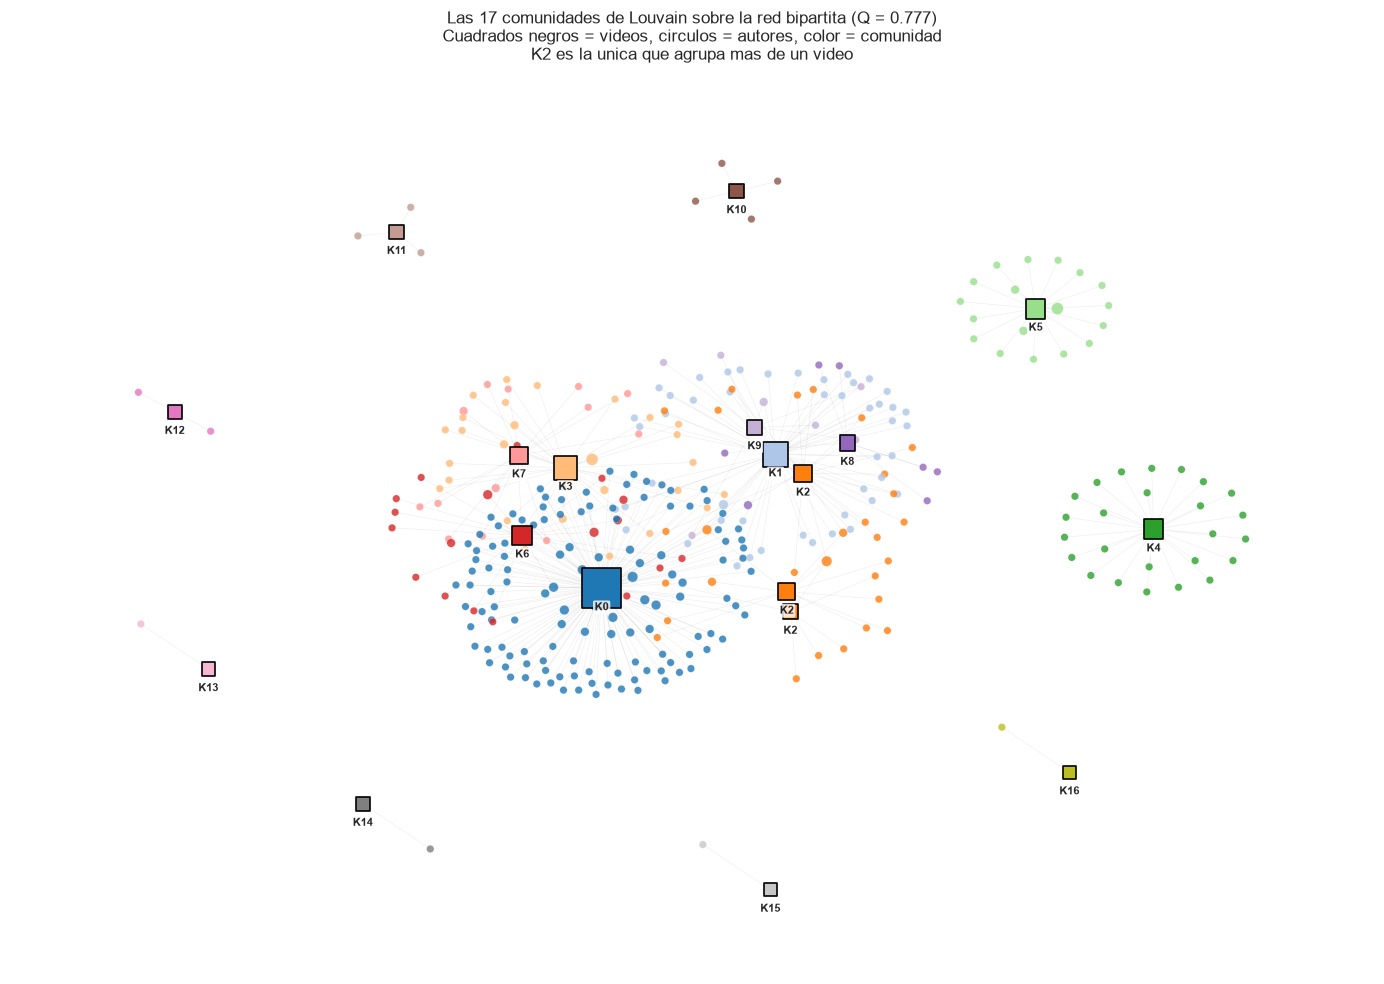

In [6]:
fig, ax = plt.subplots(figsize=(14, 10))

componentes = sorted(nx.connected_components(B), key=len, reverse=True)
pos = {}
pos.update(nx.spring_layout(B.subgraph(componentes[0]), seed=SEMILLA, k=0.30, scale=1.0))
sueltas = componentes[1:]
for i, comp in enumerate(sueltas):
    angulo = 2 * np.pi * i / len(sueltas)
    centro = np.array([1.75 * np.cos(angulo), 1.75 * np.sin(angulo)])
    escala = 0.10 + 0.22 * (len(comp) / len(componentes[1]))
    for nodo, coord in nx.spring_layout(B.subgraph(comp), seed=SEMILLA, scale=escala).items():
        pos[nodo] = coord + centro

paleta = sns.color_palette("tab20", len(comunidades))
colores = [paleta[pertenencia[n]] for n in B.nodes()]
formas_video = [n for n in B.nodes() if B.nodes[n]["tipo"] == redes.VIDEO]
formas_autor = [n for n in B.nodes() if B.nodes[n]["tipo"] == redes.AUTOR]

nx.draw_networkx_edges(B, pos, alpha=0.16, width=0.45, edge_color="#999999", ax=ax)
nx.draw_networkx_nodes(
    B, pos, nodelist=formas_autor,
    node_size=[20 + 9 * B.degree(n, weight="weight") for n in formas_autor],
    node_color=[paleta[pertenencia[n]] for n in formas_autor],
    alpha=0.8, linewidths=0.2, edgecolors="white", ax=ax,
)
nx.draw_networkx_nodes(
    B, pos, nodelist=formas_video, node_shape="s",
    node_size=[90 + 4.5 * B.degree(n, weight="weight") for n in formas_video],
    node_color=[paleta[pertenencia[n]] for n in formas_video],
    alpha=1.0, linewidths=1.2, edgecolors="black", ax=ax,
)
for n in formas_video:
    x, y = pos[n]
    ax.annotate(
        f"K{pertenencia[n]}", (x, y), fontsize=8, fontweight="bold",
        ha="center", va="top", xytext=(0, -10), textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8),
    )

ax.set_title(
    f"Las {len(comunidades)} comunidades de Louvain sobre la red bipartita (Q = {Q:.3f})\n"
    "Cuadrados negros = videos, circulos = autores, color = comunidad\n"
    "K2 es la unica que agrupa mas de un video",
    fontsize=12, pad=14,
)
ax.axis("off")
ax.margins(0.06)
plt.tight_layout()
plt.savefig(config.FIGURAS / "07_comunidades.png", dpi=150, bbox_inches="tight")
plt.show()

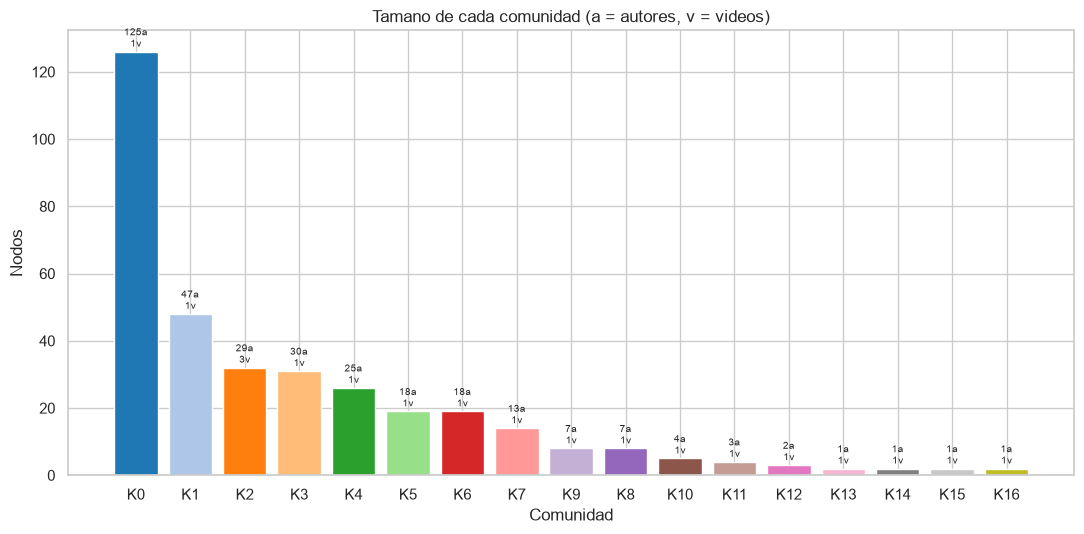

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
orden = tabla.sort_values("nodos", ascending=False)
barras = ax.bar(
    orden["comunidad"], orden["nodos"],
    color=[paleta[int(c[1:])] for c in orden["comunidad"]],
    edgecolor="white",
)
for barra, autores_n, videos_n in zip(barras, orden["autores"], orden["videos"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2, barra.get_height() + 1.5,
        f"{autores_n}a\n{videos_n}v", ha="center", fontsize=7.5,
    )
ax.set_ylabel("Nodos")
ax.set_xlabel("Comunidad")
ax.set_title("Tamano de cada comunidad (a = autores, v = videos)")
plt.tight_layout()
plt.savefig(config.FIGURAS / "07_tamanos_comunidades.png", dpi=150, bbox_inches="tight")
plt.show()

## 7.5 Caracterización de las comunidades

Se caracteriza cada una por videos, canal, autores, intensidad de
participación, temas frecuentes y sentimiento. El sentimiento se calcula con
el léxico en español de `src/sentimiento.py` sobre `texto_original`; el
ejercicio 9 lo desarrolla y justifica en detalle.

In [8]:
def caracterizar(indice: int, n_palabras: int = 8) -> dict:
    grupo = comunidades[indice]
    ids_video = [B.nodes[n]["id_original"] for n in grupo if B.nodes[n]["tipo"] == redes.VIDEO]
    sub = comentarios[comentarios["video_id"].isin(ids_video)]
    palabras = Counter()
    for t in sub["texto_limpio"]:
        palabras.update(t.split())
    reparto = sub["sentimiento_etiqueta"].value_counts()
    return {
        "comunidad": f"K{indice}",
        "videos": len(ids_video),
        "titulos": [B.nodes[n]["etiqueta"] for n in grupo if B.nodes[n]["tipo"] == redes.VIDEO],
        "canal": ", ".join(sorted(sub["channel_name"].unique())),
        "autores": sub["author_channel_id"].nunique(),
        "comentarios": len(sub),
        "coment_por_autor": round(len(sub) / max(sub["author_channel_id"].nunique(), 1), 2),
        "me_gusta_total": int(sub["me_gusta"].sum()),
        "vistas": int(videos[videos["video_id"].isin(ids_video)]["vistas"].sum()),
        "temas": [p for p, _ in palabras.most_common(n_palabras)],
        "sentimiento_medio": round(sub["sentimiento"].mean(), 3),
        "% negativo": round(100 * reparto.get("negativo", 0) / len(sub), 1),
        "% neutro": round(100 * reparto.get("neutro", 0) / len(sub), 1),
        "% positivo": round(100 * reparto.get("positivo", 0) / len(sub), 1),
    }


perfiles = [caracterizar(i) for i in range(len(comunidades))]
resumen_perfiles = pd.DataFrame(perfiles).drop(columns=["titulos", "temas"])
print(resumen_perfiles.to_string(index=False))

comunidad  videos                                 canal  autores  comentarios  coment_por_autor  me_gusta_total  vistas  sentimiento_medio  % negativo  % neutro  % positivo
       K0       1                                Quorum      128          161              1.26             358   11775             -0.139        36.0      46.0        18.0
       K1       1                                Quorum       49           50              1.02              91   10156             -0.004        30.0      40.0        30.0
       K2       3                                Quorum       29           34              1.17              17    3093              0.201        17.6      32.4        50.0
       K3       1 Gobierno de la República de Guatemala       32           45              1.41              90   11670              0.159        22.2      26.7        51.1
       K4       1            Municipalidad de Guatemala       25           25              1.00            1697  304089              0.

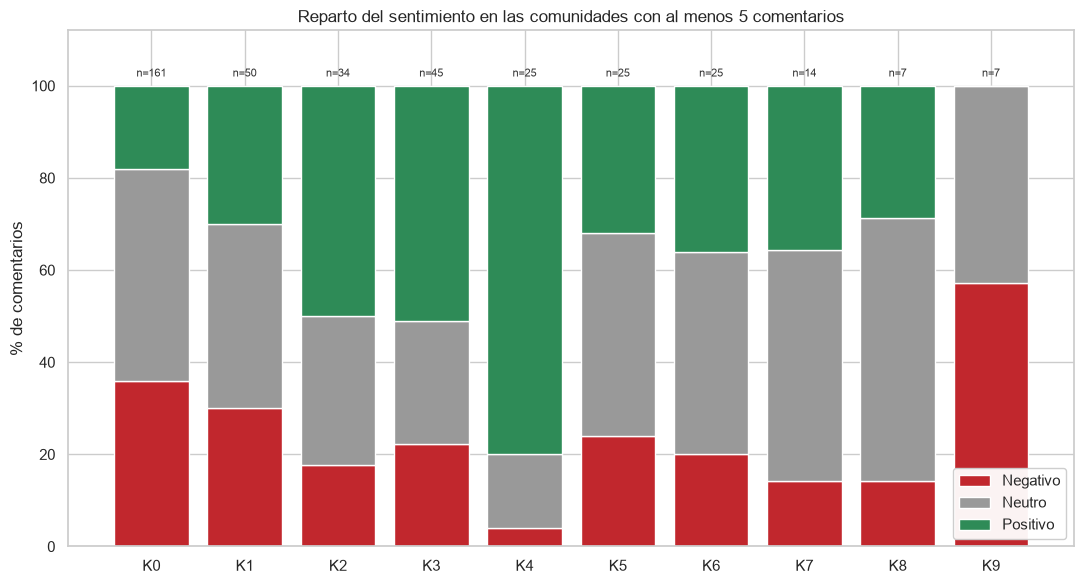

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
grandes = [p for p in perfiles if p["comentarios"] >= 5]
etiquetas = [p["comunidad"] for p in grandes]
abajo = np.zeros(len(grandes))
for clave, color in (
    ("% negativo", config.COLORES["negativo"]),
    ("% neutro", config.COLORES["neutro"]),
    ("% positivo", config.COLORES["positivo"]),
):
    valores = [p[clave] for p in grandes]
    ax.bar(etiquetas, valores, bottom=abajo, color=color, label=clave.replace("% ", "").capitalize(), edgecolor="white")
    abajo += np.array(valores)

for i, p in enumerate(grandes):
    ax.text(i, 102, f"n={p['comentarios']}", ha="center", fontsize=8, color="#333333")

ax.set_ylabel("% de comentarios")
ax.set_ylim(0, 112)
ax.set_title("Reparto del sentimiento en las comunidades con al menos 5 comentarios")
ax.legend(loc="lower right", framealpha=0.95)
plt.tight_layout()
plt.savefig(config.FIGURAS / "07_sentimiento_comunidades.png", dpi=150, bbox_inches="tight")
plt.show()

### Las tres comunidades principales

In [10]:
for indice in range(3):
    p = perfiles[indice]
    print("=" * 78)
    print(f"COMUNIDAD {p['comunidad']}  —  {p['videos']} video(s), {p['autores']} autores, {p['comentarios']} comentarios")
    print("=" * 78)
    for t in p["titulos"]:
        print(f"  · {t}")
    print(f"\n  Canal                  : {p['canal']}")
    print(f"  Vistas de los videos   : {p['vistas']:,}")
    print(f"  Comentarios por autor  : {p['coment_por_autor']}")
    print(f"  'Me gusta' acumulados  : {p['me_gusta_total']:,}")
    print(f"  Temas frecuentes       : {', '.join(p['temas'])}")
    print(f"  Sentimiento medio      : {p['sentimiento_medio']:+.3f}")
    print(f"  Reparto                : {p['% negativo']}% negativo / {p['% neutro']}% neutro / {p['% positivo']}% positivo")

    ids_video = [n for n in comunidades[indice] if B.nodes[n]["tipo"] == redes.VIDEO]
    sub = comentarios[comentarios["video_id"].isin([B.nodes[n]["id_original"] for n in ids_video])]
    extremo = sub.loc[sub["sentimiento"].idxmin()]
    print(f"\n  Comentario mas negativo ({extremo['sentimiento']:+.3f}):")
    print(f"    \"{extremo['texto_original'][:150].strip()}\"")
    print()

COMUNIDAD K0  —  1 video(s), 128 autores, 161 comentarios
  · Qué rico come tu diputado

  Canal                  : Quorum
  Vistas de los videos   : 11,775
  Comentarios por autor  : 1.26
  'Me gusta' acumulados  : 358
  Temas frecuentes       : pueblo, dinero, diputados, trabajo, diputado, sueldo, corruptos, almuerzo
  Sentimiento medio      : -0.139
  Reparto                : 36.0% negativo / 46.0% neutro / 18.0% positivo

  Comentario mas negativo (-0.958):
    "Entoces las mismas 💩😡 Junta Directiva haciéndose de las suyas con el dinero del Estado. Ya basta de tanto robo, barriles sin fondos..💩😡"

COMUNIDAD K1  —  1 video(s), 49 autores, 50 comentarios
  · La cooptación de Walter Mazariegos en la USAC

  Canal                  : Quorum
  Vistas de los videos   : 10,156
  Comentarios por autor  : 1.02
  'Me gusta' acumulados  : 91
  Temas frecuentes       : usac, corruptos, universidad, estudiantes, excelente, información, pueblo, pacto
  Sentimiento medio      : -0.004
  Reparto   

### Lectura de las tres principales

**K0 — «Qué rico come tu diputado» (Quorum, 161 comentarios de 128 autores).**
Es la comunidad dominante: sola reúne el 39.7 % de todos los comentarios de
la muestra. El video es un reportaje sobre el gasto en alimentación de los
diputados, y el vocabulario del público lo refleja sin ambigüedad: *diputados,
pueblo, sueldo, almuerzo, corruptos, dinero*. Con 36 % de comentarios
negativos es la más negativa de las comunidades grandes —K9 y K12 tienen
medias peores, pero con siete y dos comentarios no sostienen una
comparación—, y la negatividad no es difusa sino dirigida a un objeto
concreto, el Congreso. La intensidad es baja, 1.26 comentarios por autor, lo
que describe a un público de indignación puntual antes que a una conversación
sostenida.

*(Detalle de lectura: la comunidad tiene 125 nodos de autor pero el video
recibió comentarios de 128 personas. La diferencia son tres autores puente
que Louvain asignó a otra comunidad. Las cifras de esta sección se calculan
sobre los comentarios de los videos de cada comunidad, no sobre sus nodos.)*

**K1 — «La cooptación de Walter Mazariegos en la USAC» (Quorum, 50
comentarios de 49 autores).** Segunda en tamaño y temáticamente contigua a
K0: universidad pública, rectoría, elecciones internas. Comparte con K0 dos
autores puente, que es la arista de peso 2 más fuerte de toda la proyección
video-video. El tono queda partido por la mitad —30 % negativo y 30 %
positivo, media prácticamente nula— y aparece con más frecuencia vocabulario
institucional (*usac, estudiantes, universidad*) que insulto directo; parte
de lo positivo son felicitaciones al medio por el reportaje, no al hecho
reportado.

**K2 — Los tres videos urbanos de Quorum (34 comentarios de 29 autores).** Ésta es la
única comunidad que el algoritmo construye en lugar de heredar. Junta
*Internet: escoger el menos malo*, *Arroz con pollo a la MONOPOLIO* y
*Caminar en una ciudad hecha para carros*: tres piezas sobre servicios,
precios y movilidad urbana. Que hayan quedado juntas significa que existe un
núcleo pequeño de personas que sigue a Quorum como canal y no sólo un video
viral suyo. Es la evidencia más clara de audiencia compartida en todo el
laboratorio, y aun así son 29 autores de 332.

### Lo que la caracterización dice en conjunto

El sentimiento separa a las comunidades de forma nítida y en la dirección
esperable por el canal: las comunidades formadas alrededor de videos de medios
críticos (Quorum) son marcadamente negativas, mientras que las formadas
alrededor de videos de canales institucionales —«Inician los trabajos de
recuperación del Puente Belice II» del Gobierno, «Plan 2032» de la
Municipalidad— tienen la proporción más alta de comentarios positivos, con
felicitaciones y agradecimientos.

Ahora bien, esa asociación **no debe leerse como que el canal causa el tono**.
Lo más probable es lo contrario o algo mixto: los videos de denuncia atraen a
quien ya está molesto, y los anuncios de obra pública atraen a quien celebra.
Con estos datos no se puede separar una cosa de la otra, y el ejercicio 10
vuelve sobre esta distinción entre asociación e inferencia.

In [11]:
comparacion_canal = comentarios.groupby("channel_name").agg(
    comentarios=("comment_id", "size"),
    autores=("author_channel_id", "nunique"),
    sentimiento_medio=("sentimiento", "mean"),
).sort_values("comentarios", ascending=False)
comparacion_canal["sentimiento_medio"] = comparacion_canal["sentimiento_medio"].round(3)
comparacion_canal["% negativo"] = (
    comentarios.groupby("channel_name")["sentimiento_etiqueta"]
    .apply(lambda s: 100 * (s == "negativo").mean())
    .round(1)
)
print("Sentimiento por canal (contexto para la lectura de las comunidades):")
print(comparacion_canal.to_string())

Sentimiento por canal (contexto para la lectura de las comunidades):
                                       comentarios  autores  sentimiento_medio  % negativo
channel_name                                                                              
Quorum                                         256      214             -0.049        31.6
Gobierno de la República de Guatemala           70       50              0.142        21.4
Municipalidad de Guatemala                      25       25              0.436         4.0
Noticias Telemundo                              25       18              0.045        24.0
Noti7                                           14       13              0.135        14.3
PrensaLibreOficial                               7        7              0.084        14.3
TN23 Guatemala                                   7        7             -0.285        57.1
Noticiero Guatevisión 13 Hrs.                    2        2             -0.170        50.0
